# AlexNet-style Image Classification on CIFAR-10

## Research question

What classification performance and class-level error patterns does an
AlexNet-style convolutional neural network achieve when adapted from large
ImageNet images to 32 × 32 CIFAR-10 images?

## Purpose

This notebook establishes a clean baseline for the shortcut-learning
experiment in notebook 2.

It covers:

1. adaptation of the AlexNet architecture;
2. training and validation-based checkpoint selection;
3. final held-out test evaluation;
4. class-level error analysis.

The project is an AlexNet-style adaptation, not an exact reproduction of the
original ImageNet experiment.

In [2]:
import json
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report
)
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

In [3]:
SEED = 42

BATCH_SIZE = 64
NUM_EPOCHS = 10

LEARNING_RATE = 0.01
MOMENTUM = 0.9
WEIGHT_DECAY = 0.0005

TRAIN_SIZE = 45_000
VAL_SIZE = 5_000


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)

# Improve reproducibility when CUDA is used.
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

project_directory = Path.cwd()

if project_directory.name == "notebooks":
    project_directory = project_directory.parent

data_directory = project_directory / "data"
checkpoint_directory = project_directory / "checkpoints"
report_directory = project_directory / "reports"

checkpoint_directory.mkdir(parents=True, exist_ok=True)
report_directory.mkdir(parents=True, exist_ok=True)

print("Device:", device)
print("Project directory:", project_directory)
print("Checkpoint directory:", checkpoint_directory)
print("Report directory:", report_directory)

Device: cuda
Project directory: /content
Checkpoint directory: /content/checkpoints
Report directory: /content/reports


## Dataset and preprocessing

CIFAR-10 contains 50,000 training images and 10,000 official test images from
ten balanced classes.

The original training partition is divided into:

- 45,000 training images;
- 5,000 validation images.

The official test partition remains separate until final evaluation.

Images are converted to tensors and normalized from `[0, 1]` to approximately
`[-1, 1]` in each colour channel.

Data augmentation is not used in this baseline. This keeps preprocessing
identical to the shortcut-learning experiment, although it may limit
classification performance.

In [5]:
preprocess = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5)
    )
])

full_training_dataset = datasets.CIFAR10(
    root=data_directory,
    train=True,
    download=True,  # Downloads only if the dataset is missing
    transform=preprocess
)

split_generator = torch.Generator().manual_seed(SEED)

train_dataset, val_dataset = random_split(
    full_training_dataset,
    [TRAIN_SIZE, VAL_SIZE],
    generator=split_generator
)

train_indices = train_dataset.indices
val_indices = val_dataset.indices
class_names = full_training_dataset.classes

print("Full training partition:", len(full_training_dataset))
print("Training subset:", len(train_dataset))
print("Validation subset:", len(val_dataset))
print("Classes:", class_names)

100%|██████████| 170M/170M [04:32<00:00, 625kB/s]


Full training partition: 50000
Training subset: 45000
Validation subset: 5000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
# The dedicated generator controls training-data shuffling without
# depending on other random operations in the notebook.
shuffle_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=shuffle_generator,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Training batches: 704
Validation batches: 79


In [7]:
class AlexNetCIFAR10(nn.Module):
    def __init__(self, num_classes=10, dropout=0.5):
        super().__init__()

        self.features = nn.Sequential(
            # Input: 3 × 32 × 32
            nn.Conv2d(
                in_channels=3,
                out_channels=96,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1
            ),

            # 96 × 16 × 16
            nn.Conv2d(
                in_channels=96,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1
            ),

            # 256 × 8 × 8
            nn.Conv2d(
                in_channels=256,
                out_channels=384,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=384,
                out_channels=384,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                in_channels=384,
                out_channels=256,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(
                kernel_size=3,
                stride=2,
                padding=1
            )
        )

        self.avgpool = nn.AdaptiveAvgPool2d((2, 2))

        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(256 * 2 * 2, 1024),
            nn.ReLU(inplace=True),

            nn.Dropout(p=dropout),
            nn.Linear(1024, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, num_classes)
        )

    def forward(self, images):
        features = self.features(images)
        pooled_features = self.avgpool(features)

        flattened_features = torch.flatten(
            pooled_features,
            start_dim=1
        )

        return self.classifier(flattened_features)

In [8]:
# Reset immediately before model initialization.
set_seed(SEED)

model = AlexNetCIFAR10().to(device)

total_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
)

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

# Use a validation batch so the shuffled training loader is not advanced.
validation_images, _ = next(iter(val_loader))
validation_images = validation_images.to(device)

model.eval()

with torch.no_grad():
    sample_outputs = model(validation_images)

model.train()

print("Input shape:", validation_images.shape)
print("Output shape:", sample_outputs.shape)
print(f"Total parameters: {total_parameters:,}")
print(f"Trainable parameters: {trainable_parameters:,}")

Input shape: torch.Size([64, 3, 32, 32])
Output shape: torch.Size([64, 10])
Total parameters: 4,901,258
Trainable parameters: 4,901,258


## Differences from the original AlexNet

| Component | Original AlexNet | CIFAR-10 adaptation |
|---|---|---|
| Dataset | ImageNet | CIFAR-10 |
| Input size | Approximately 224–227 pixels | 32 × 32 pixels |
| Output classes | 1,000 | 10 |
| First convolution | 11 × 11, stride 4 | 3 × 3, stride 1 |
| Convolutional layers | Five | Five |
| Fully connected layers | Three | Three |
| Hidden classifier sizes | 4,096 and 4,096 | 1,024 and 512 |
| Activation | ReLU | ReLU |
| Pooling | Overlapping max pooling | Overlapping max pooling |
| Dropout | Used | Used |
| Local response normalization | Used | Omitted |
| Grouped convolutions | Used because of two-GPU training | Omitted |
| Data augmentation | Used | Omitted in this controlled baseline |

The large first convolution and classifier from the original network would be
poorly suited to 32 × 32 inputs. This version preserves the five-convolution,
three-linear-layer structure while reducing kernels, spatial dimensions and
classifier size.

Because several original components and the dataset have changed, this should
be described as an AlexNet-style adaptation rather than a reproduction.

In [9]:
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=LEARNING_RATE,
    momentum=MOMENTUM,
    weight_decay=WEIGHT_DECAY
)

best_checkpoint_path = checkpoint_directory / "best.pt"
latest_checkpoint_path = checkpoint_directory / "latest.pt"

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__)

Loss: CrossEntropyLoss()
Optimizer: SGD


In [10]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    loss_sum = 0.0
    correct = 0

    for batch_number, (images, labels) in enumerate(
        loader,
        start=1
    ):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * labels.size(0)

        predictions = outputs.argmax(dim=1)
        correct += (predictions == labels).sum().item()

        if batch_number % 200 == 0:
            print(
                f"Batch {batch_number}/{len(loader)}"
            )

    dataset_size = len(loader.dataset)

    return {
        "loss": loss_sum / dataset_size,
        "accuracy": correct / dataset_size
    }


def evaluate_model(model, loader, criterion, device):
    model.eval()

    loss_sum = 0.0
    actual = []
    predicted = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss_sum += loss.item() * labels.size(0)

            predictions = outputs.argmax(dim=1)

            actual.extend(labels.cpu().tolist())
            predicted.extend(predictions.cpu().tolist())

    dataset_size = len(actual)

    correct = sum(
        true == prediction
        for true, prediction in zip(actual, predicted)
    )

    return {
        "loss": loss_sum / dataset_size,
        "accuracy": correct / dataset_size,
        "correct": correct,
        "actual": actual,
        "predicted": predicted
    }

In [11]:
history = []
best_val_accuracy = -1.0
best_epoch = None

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")

    train_result = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_result = evaluate_model(
        model,
        val_loader,
        criterion,
        device
    )

    history.append({
        "epoch": epoch,
        "train_loss": train_result["loss"],
        "train_accuracy": train_result["accuracy"],
        "val_loss": val_result["loss"],
        "val_accuracy": val_result["accuracy"]
    })

    improved = val_result["accuracy"] > best_val_accuracy

    if improved:
        best_val_accuracy = val_result["accuracy"]
        best_epoch = epoch

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_val_accuracy": best_val_accuracy,
        "history": history,
        "train_indices": train_indices,
        "val_indices": val_indices,
        "class_names": class_names,
        "config": {
            "seed": SEED,
            "batch_size": BATCH_SIZE,
            "epochs": NUM_EPOCHS,
            "learning_rate": LEARNING_RATE,
            "momentum": MOMENTUM,
            "weight_decay": WEIGHT_DECAY,
            "normalization_mean": [0.5, 0.5, 0.5],
            "normalization_std": [0.5, 0.5, 0.5]
        }
    }

    torch.save(checkpoint, latest_checkpoint_path)

    if improved:
        torch.save(checkpoint, best_checkpoint_path)

    print(
        f"Train loss: {train_result['loss']:.4f} | "
        f"Train accuracy: {train_result['accuracy']:.1%} | "
        f"Val loss: {val_result['loss']:.4f} | "
        f"Val accuracy: {val_result['accuracy']:.1%}"
    )

print("\nTraining complete.")
print("Selected epoch:", best_epoch)
print(f"Best validation accuracy: {best_val_accuracy:.2%}")


Epoch 1/10
Batch 200/704
Batch 400/704
Batch 600/704
Train loss: 2.1734 | Train accuracy: 15.5% | Val loss: 1.8357 | Val accuracy: 29.8%

Epoch 2/10
Batch 200/704
Batch 400/704
Batch 600/704
Train loss: 1.7069 | Train accuracy: 33.8% | Val loss: 1.4667 | Val accuracy: 43.1%

Epoch 3/10
Batch 200/704
Batch 400/704
Batch 600/704
Train loss: 1.4228 | Train accuracy: 46.0% | Val loss: 1.3153 | Val accuracy: 51.9%

Epoch 4/10
Batch 200/704
Batch 400/704
Batch 600/704
Train loss: 1.2142 | Train accuracy: 55.6% | Val loss: 1.1935 | Val accuracy: 55.8%

Epoch 5/10
Batch 200/704
Batch 400/704
Batch 600/704
Train loss: 1.0204 | Train accuracy: 63.7% | Val loss: 0.9393 | Val accuracy: 65.8%

Epoch 6/10
Batch 200/704
Batch 400/704
Batch 600/704
Train loss: 0.8828 | Train accuracy: 68.8% | Val loss: 0.9323 | Val accuracy: 65.9%

Epoch 7/10
Batch 200/704
Batch 400/704
Batch 600/704
Train loss: 0.7698 | Train accuracy: 73.1% | Val loss: 0.7799 | Val accuracy: 72.3%

Epoch 8/10
Batch 200/704
Batch 40

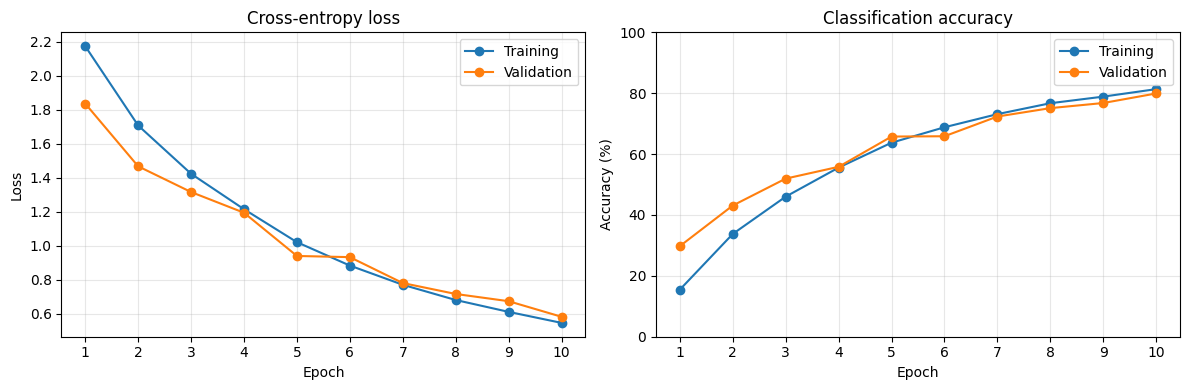

In [12]:
history_frame = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(
    history_frame["epoch"],
    history_frame["train_loss"],
    marker="o",
    label="Training"
)

axes[0].plot(
    history_frame["epoch"],
    history_frame["val_loss"],
    marker="o",
    label="Validation"
)

axes[1].plot(
    history_frame["epoch"],
    100 * history_frame["train_accuracy"],
    marker="o",
    label="Training"
)

axes[1].plot(
    history_frame["epoch"],
    100 * history_frame["val_accuracy"],
    marker="o",
    label="Validation"
)

axes[0].set_title("Cross-entropy loss")
axes[0].set_ylabel("Loss")

axes[1].set_title("Classification accuracy")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 100)

for axis in axes:
    axis.set_xlabel("Epoch")
    axis.set_xticks(history_frame["epoch"])
    axis.grid(alpha=0.3)
    axis.legend()

fig.tight_layout()
fig.savefig(
    report_directory / "baseline_learning_curves.png",
    dpi=200
)

plt.show()

In [13]:
best_checkpoint = torch.load(
    best_checkpoint_path,
    map_location=device,
    weights_only=True
)

evaluation_model = AlexNetCIFAR10().to(device)

evaluation_model.load_state_dict(
    best_checkpoint["model_state_dict"]
)

evaluation_model.eval()

print("Loaded checkpoint from epoch:", best_checkpoint["epoch"])
print(
    "Checkpoint validation accuracy:",
    f"{best_checkpoint['best_val_accuracy']:.2%}"
)

Loaded checkpoint from epoch: 10
Checkpoint validation accuracy: 79.92%


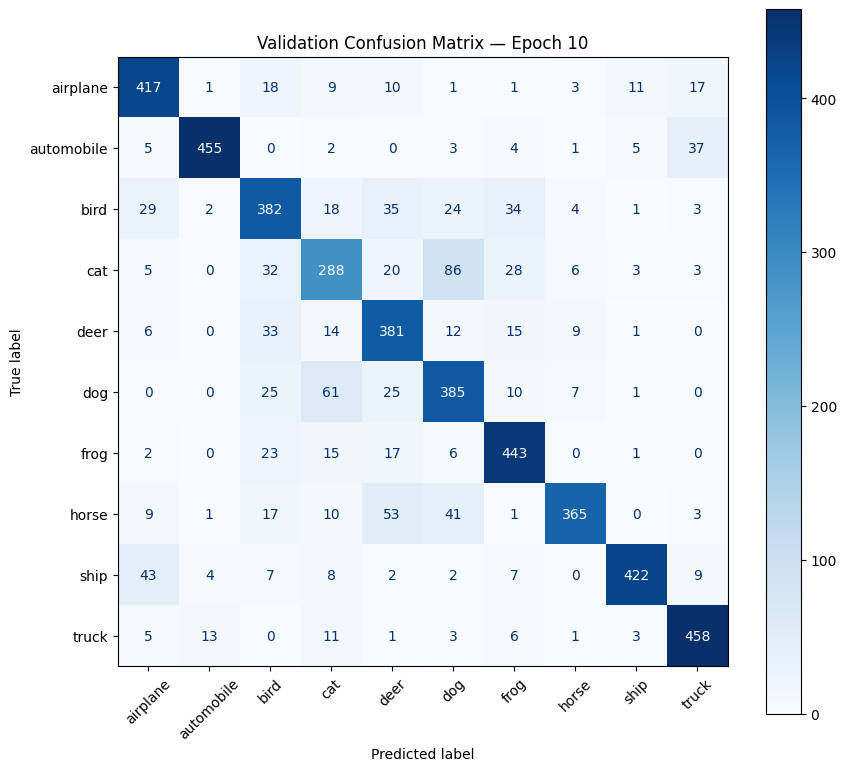

In [14]:
val_result = evaluate_model(
    evaluation_model,
    val_loader,
    criterion,
    device
)

fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    val_result["actual"],
    val_result["predicted"],
    labels=list(range(10)),
    display_labels=class_names,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    "Validation Confusion Matrix — "
    f"Epoch {best_checkpoint['epoch']}"
)

fig.tight_layout()
fig.savefig(
    report_directory / "baseline_validation_confusion_matrix.png",
    dpi=200
)

plt.show()

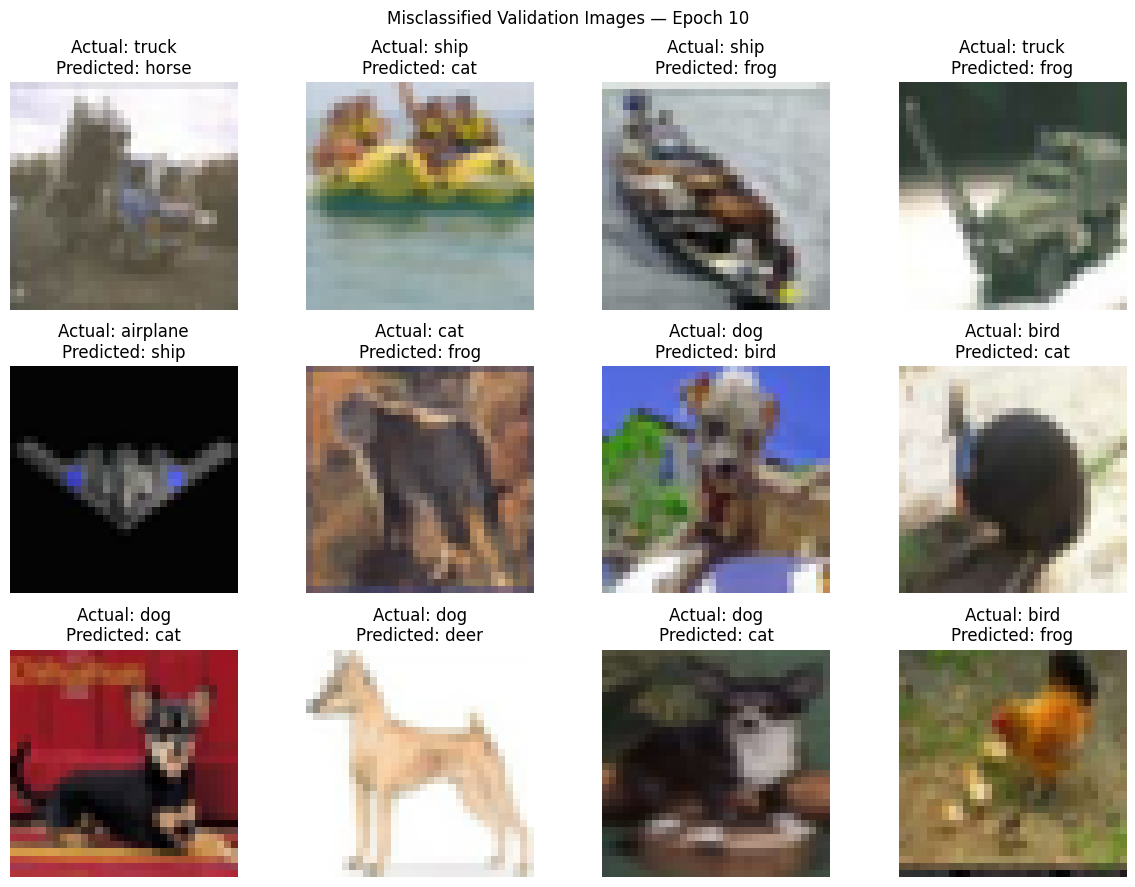

In [15]:
wrong_indices = [
    index
    for index, (actual, predicted) in enumerate(
        zip(
            val_result["actual"],
            val_result["predicted"]
        )
    )
    if actual != predicted
]

fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for axis in axes.flat:
    axis.axis("off")

for axis, index in zip(
    axes.flat,
    wrong_indices[:12]
):
    image, true_label = val_dataset[index]

    predicted_label = (
        val_result["predicted"][index]
    )

    display_image = (
        image * 0.5 + 0.5
    ).clamp(0, 1)

    display_image = display_image.permute(
        1, 2, 0
    ).numpy()

    axis.imshow(
        display_image,
        interpolation="nearest"
    )

    axis.set_title(
        f"Actual: {class_names[true_label]}\n"
        f"Predicted: {class_names[predicted_label]}"
    )

fig.suptitle(
    "Misclassified Validation Images — "
    f"Epoch {best_checkpoint['epoch']}"
)

fig.tight_layout()
fig.savefig(
    report_directory / "baseline_validation_mistakes.png",
    dpi=200
)

plt.show()

## Final held-out test evaluation

The best checkpoint was selected using validation accuracy. The model is now
evaluated once on the official CIFAR-10 test partition.

The test data was not used to select an epoch, change hyperparameters or update
the model's weights.

Accuracy measures the overall proportion of correct predictions. Macro F1 gives
equal importance to each class, while class-level precision and recall reveal
errors hidden by aggregate accuracy.

In [16]:
test_dataset = datasets.CIFAR10(
    root=data_directory,
    train=False,
    download=True,
    transform=preprocess
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_result = evaluate_model(
    evaluation_model,
    test_loader,
    criterion,
    device
)

assert len(test_result["actual"]) == 10_000

print("Selected epoch:", best_checkpoint["epoch"])
print(
    f"Test accuracy: {test_result['accuracy']:.2%} "
    f"({test_result['correct']}/10000)"
)
print(f"Test loss: {test_result['loss']:.4f}")

Selected epoch: 10
Test accuracy: 79.72% (7972/10000)
Test loss: 0.6049


In [17]:
test_report = classification_report(
    test_result["actual"],
    test_result["predicted"],
    labels=list(range(10)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

test_macro_f1 = (
    test_report["macro avg"]["f1-score"]
)

test_per_class = (
    pd.DataFrame(test_report)
    .T
    .loc[class_names]
    .copy()
)

test_per_class["support"] = (
    test_per_class["support"].astype(int)
)

print(f"Macro F1: {test_macro_f1:.4f}")

display(test_per_class.round(4))

Macro F1: 0.7971


,precision,recall,f1-score,support
airplane,0.7829,0.844,0.8123,1000
automobile,0.9383,0.882,0.9093,1000
bird,0.6984,0.734,0.7157,1000
cat,0.6926,0.588,0.6360,1000
deer,0.7156,0.858,0.7804,1000
dog,0.6914,0.755,0.7218,1000
frog,0.8088,0.863,0.8350,1000
horse,0.9129,0.713,0.8007,1000
ship,0.9282,0.840,0.8819,1000
truck,0.8622,0.895,0.8783,1000


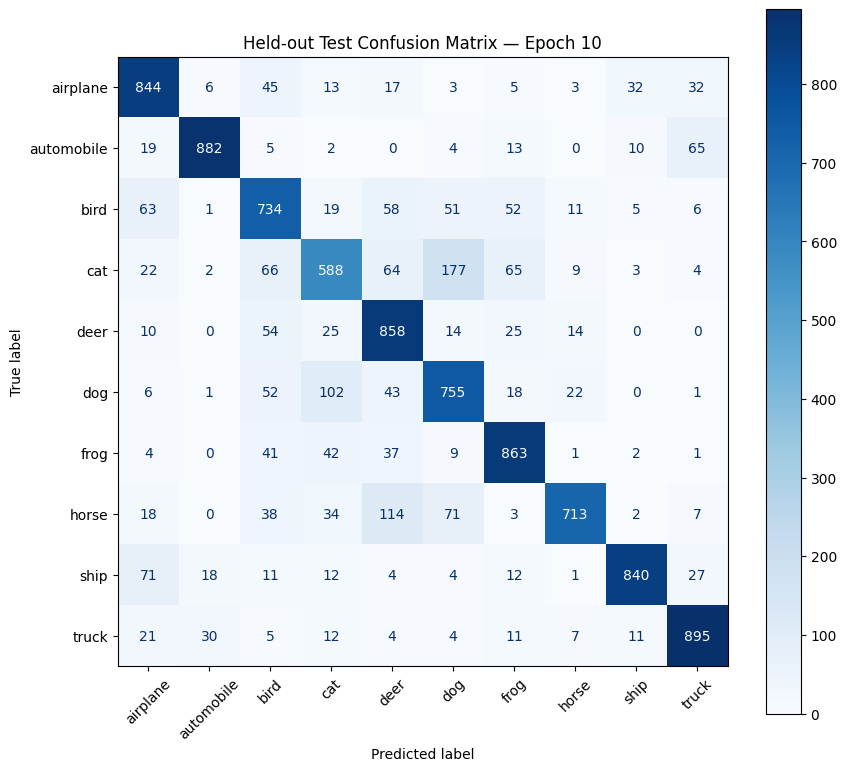

In [18]:
fig, ax = plt.subplots(figsize=(9, 8))

ConfusionMatrixDisplay.from_predictions(
    test_result["actual"],
    test_result["predicted"],
    labels=list(range(10)),
    display_labels=class_names,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    ax=ax
)

ax.set_title(
    "Held-out Test Confusion Matrix — "
    f"Epoch {best_checkpoint['epoch']}"
)

fig.tight_layout()
fig.savefig(
    report_directory / "baseline_test_confusion_matrix.png",
    dpi=200
)

plt.show()

In [19]:
f1_ranking = test_per_class[
    "f1-score"
].sort_values()

weakest_classes = f1_ranking.head(3)
strongest_classes = f1_ranking.tail(3).sort_values(
    ascending=False
)

print("Lowest class F1 scores:")
display(weakest_classes.to_frame("F1 score").round(4))

print("Highest class F1 scores:")
display(strongest_classes.to_frame("F1 score").round(4))

Lowest class F1 scores:


,F1 score
cat,0.6360
bird,0.7157
dog,0.7218


Highest class F1 scores:


,F1 score
automobile,0.9093
ship,0.8819
truck,0.8783


In [20]:
history_frame.to_csv(
    report_directory / "training_history.csv",
    index=False
)

test_per_class.to_csv(
    report_directory / "test_per_class.csv",
    index_label="class"
)

test_predictions = pd.DataFrame({
    "test_index": range(len(test_result["actual"])),
    "actual": test_result["actual"],
    "predicted": test_result["predicted"]
})

test_predictions.to_csv(
    report_directory / "test_predictions.csv",
    index=False
)

results = {
    "selected_epoch": best_checkpoint["epoch"],
    "validation_accuracy": best_checkpoint["best_val_accuracy"],
    "test_images": len(test_result["actual"]),
    "test_correct": test_result["correct"],
    "test_accuracy": test_result["accuracy"],
    "test_loss": test_result["loss"],
    "test_macro_f1": test_macro_f1,
    "seed": SEED,
    "classification_report": test_report
}

(report_directory / "test_results.json").write_text(
    json.dumps(results, indent=2),
    encoding="utf-8"
)

print("Reports saved to:", report_directory)

Reports saved to: /content/reports


In [22]:
from sklearn.metrics import confusion_matrix

selected_epoch = best_checkpoint["epoch"]
validation_accuracy = best_checkpoint["best_val_accuracy"]
test_accuracy = test_result["accuracy"]

accuracy_difference = test_accuracy - validation_accuracy
difference_direction = (
    "higher" if accuracy_difference >= 0 else "lower"
)

matrix = confusion_matrix(
    test_result["actual"],
    test_result["predicted"]
)
# Remove correct predictions to find the most common mistake.
mistakes_only = matrix.copy()
np.fill_diagonal(mistakes_only, 0)

true_index, predicted_index = np.unravel_index(
    mistakes_only.argmax(),
    mistakes_only.shape
)

print("Selected epoch:", selected_epoch)
print(f"Validation accuracy: {validation_accuracy:.2%}")
print(f"Test accuracy: {test_accuracy:.2%}")
print(f"Test loss: {test_result['loss']:.4f}")
print(f"Macro F1: {test_macro_f1:.4f}")

print(
    "Accuracy difference:",
    f"{abs(100 * accuracy_difference):.2f}",
    f"percentage points {difference_direction}"
)

print("\nWeakest classes:")
for class_name, score in weakest_classes.items():
    print(f"- {class_name}: {score:.4f}")

print("\nStrongest classes:")
for class_name, score in strongest_classes.items():
    print(f"- {class_name}: {score:.4f}")

print(
    "\nMost common confusion:",
    class_names[true_index],
    "predicted as",
    class_names[predicted_index],
    f"({mistakes_only[true_index, predicted_index]} images)"
)


Selected epoch: 10
Validation accuracy: 79.92%
Test accuracy: 79.72%
Test loss: 0.6049
Macro F1: 0.7971
Accuracy difference: 0.20 percentage points lower

Weakest classes:
- cat: 0.6360
- bird: 0.7157
- dog: 0.7218

Strongest classes:
- automobile: 0.9093
- ship: 0.8819
- truck: 0.8783

Most common confusion: cat predicted as dog (177 images)




## Answer to the research question
The adapted AlexNet-style model learned features sufficient to achieve
79.72% test accuracy on CIFAR-10.

Its performance was not equal across all classes. Automobile, ship and
truck achieved the strongest F1 scores. Cat, bird and dog were the most
difficult classes.

This experiment provides a clean baseline for the shortcut-learning
experiment in notebook 2.

## Limitations

This is an AlexNet-style adaptation rather than a reproduction of the original
ImageNet experiment. The input resolution, convolution kernels, classifier
size, dataset and number of output classes were changed.

The result comes from one random seed and one train-validation split. Multiple
runs would be needed to estimate performance variability.

No controlled architecture ablations were performed, so the experiment does
not isolate the individual effects of depth, dropout, pooling or other model
components.

Data augmentation and learning-rate scheduling were not used. These choices
keep the baseline consistent with the shortcut experiment but may limit
classification performance.

CIFAR-10 performance does not by itself establish robustness to real-world
distribution changes. Notebook 2 separately investigates one controlled form
of synthetic distribution shift.